# Exploratory Data Analysis of Facebook Post Performance

This notebook explores engagement patterns in Facebook posts to understand which types of posts perform better.

**Sections:**
1. Data Loading
2. Initial Data Inspection
3. Data Cleaning
4. Missing Value Analysis
5. Feature Engineering
6. Engagement Metric Distributions
7. Algorithmic Exposure vs Audience Engagement
8. Posting Time Analysis
9. Key Findings Summary

## 1. Data Loading

Import libraries and load the Facebook analytics dataset.

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

data_path = Path("../data/010625_120326_fb_posts.csv")
df = pd.read_csv(data_path)

df.head()

,Post ID,Page ID,Page name,Title,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,...,Impressions,Interactions,Reactions,Saves,Shares,Views,Net follows,Viewers,Average Seconds viewed,Seconds viewed
0,10234689050595025,1461428297,Liz Izakson Mashal,אי-החלטות. \n\nאני שונאת להחליט. \n\nבמיוחד כשמצמידים לה...,0,08/03/2025 22:18,https://www.facebook.com/liz.izakson/posts/pfbid026J4jCF...,Photo,NaN,Lifetime,...,878.0,76.0,45.0,0.0,0.0,1651,NaN,683.0,NaN,NaN
1,10237913037112673,1461428297,Liz Izakson Mashal,מפגש עם ספר הוא לפעמים גם מפגש בין שני אנשים שלא הכירו ק...,0,03/11/2026 23:07,https://www.facebook.com/liz.izakson/posts/pfbid0M7SVxFx...,Content,NaN,Lifetime,...,NaN,8.0,5.0,0.0,0.0,109,NaN,71.0,NaN,NaN
2,10237860987931476,1461428297,Liz Izakson Mashal,"יש מקומות שנשארים חרוטים בגופינו.\n\nמסדרונות, מדרגות, ח...",0,03/09/2026 22:45,https://www.facebook.com/liz.izakson/posts/pfbid0psxmcEf...,Photo,NaN,Lifetime,...,1023.0,79.0,50.0,0.0,1.0,1617,NaN,904.0,NaN,NaN
3,10237836439037769,1461428297,Liz Izakson Mashal,הדבר שהכי מייצג אישה עבורי הוא שינויים. \n\nשינויים פיזי...,0,03/08/2026 10:15,https://www.facebook.com/liz.izakson/posts/pfbid02Zf79Ye...,Photo,NaN,Lifetime,...,1340.0,83.0,60.0,0.0,0.0,2204,NaN,1115.0,NaN,NaN
4,10237816770946079,1461428297,Liz Izakson Mashal,מה שמרגיע אותי בתוך הכאוס:\n\n1. לבהות בתווי הפנים הרגוע...,0,03/07/2026 09:19,https://www.facebook.com/liz.izakson/posts/pfbid02BacpAN...,Photo,NaN,Lifetime,...,716.0,51.0,28.0,0.0,0.0,1100,NaN,587.0,NaN,NaN


## 2. Initial Data Inspection

Check the dataset shape, column types, and how many non-null values exist per column.

In [349]:
# Dataset shape, column types, and null counts at a glance
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Post ID                 134 non-null    int64  
 1   Page ID                 134 non-null    int64  
 2   Page name               134 non-null    str    
 3   Title                   132 non-null    str    
 4   Duration (sec)          134 non-null    int64  
 5   Publish time            134 non-null    str    
 6   Permalink               134 non-null    str    
 7   Post type               134 non-null    str    
 8   Data comment            0 non-null      float64
 9   Date                    134 non-null    str    
 10  Comments                97 non-null     float64
 11  Distribution            96 non-null     str    
 12  Impressions             95 non-null     float64
 13  Interactions            97 non-null     float64
 14  Reactions               97 non-null     float64
 15  

## 3. Data Cleaning

Normalise column names (lowercase, no special characters) and coerce metric columns to numeric types.
We also take a first look at the post type distribution.

In [350]:
# Normalize column names: lowercase, strip whitespace, replace special characters with underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())

print("\nPost type distribution:")
print(df["post_type"].value_counts())

Cleaned column names:
['post_id', 'page_id', 'page_name', 'title', 'duration_sec_', 'publish_time', 'permalink', 'post_type', 'data_comment', 'date', 'comments', 'distribution', 'impressions', 'interactions', 'reactions', 'saves', 'shares', 'views', 'net_follows', 'viewers', 'average_seconds_viewed', 'seconds_viewed']

Post type distribution:
post_type
Photo      105
Content     20
Reel         7
Link         2
Name: count, dtype: int64


**Note on posts with no title:** A small number of posts have an empty `title` field. In this dataset, these turned out to be **cover photo changes** — Facebook does not assign a text title to those posts, and their permalink follows the `photo.php` pattern rather than the usual `/posts/` structure. They are kept in the dataset but are worth flagging when they surface (e.g. in top-N rankings).

In [351]:
# Coerce metric columns to numeric (non-parseable values become NaN)
numeric_cols = [
    "views", "comments", "impressions", "interactions",
    "reactions", "saves", "shares", "viewers",
    "average_seconds_viewed", "seconds_viewed",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Data Freshness Check

Every time new data is added to the CSV, we want to know:
- What is the current date range of the dataset?
- Were new posts added since the last run?
- What are their raw publish times? (important for verifying the correct timezone offset)

In [352]:
# Parse publish_time temporarily (raw, no correction yet) for the freshness check
_raw_times = pd.to_datetime(df["publish_time"], errors="coerce")

# Date range of the current dataset
print(f"Total posts:  {len(df)}")
print(f"Earliest post (raw): {_raw_times.min()}")
print(f"Latest post  (raw): {_raw_times.max()}")
print()

# Detect posts newer than the previous known cutoff — update KNOWN_CUTOFF when adding new data
KNOWN_CUTOFF = pd.Timestamp("2026-03-08")
new_posts = df[_raw_times > KNOWN_CUTOFF].copy()
new_posts["_raw_time"] = _raw_times[new_posts.index]

if new_posts.empty:
    print("No new posts detected since last run.")
else:
    print(f"{len(new_posts)} new post(s) detected since {KNOWN_CUTOFF.date()}:")
    print(new_posts[["_raw_time", "page_name", "post_type"]].sort_values("_raw_time").to_string(index=False))
    print()
    print("⚠️  Verify that the timezone correction in section 5.1 is correct for these posts.")

Total posts:  134
Earliest post (raw): 2025-06-04 05:49:00
Latest post  (raw): 2026-03-11 23:07:00

3 new post(s) detected since 2026-03-08:
          _raw_time          page_name post_type
2026-03-08 10:15:00 Liz Izakson Mashal     Photo
2026-03-09 22:45:00 Liz Izakson Mashal     Photo
2026-03-11 23:07:00 Liz Izakson Mashal   Content

⚠️  Verify that the timezone correction in section 5.1 is correct for these posts.


## 4. Missing Value Analysis

Identify which columns contain missing values and determine whether the missingness is structural
(i.e. a metric is simply not applicable to that post type) or genuinely absent.

In [353]:
# Count missing values per metric column
df[numeric_cols].isna().sum()

views                       0
comments                   37
impressions                39
interactions               37
reactions                  37
saves                      37
shares                     37
viewers                    43
average_seconds_viewed    127
seconds_viewed            127
dtype: int64

In [354]:
# Verify that video-only metrics (average_seconds_viewed, seconds_viewed) are
# present exclusively for Reels — explaining why they are missing for all other types.
df.groupby("post_type")[["average_seconds_viewed", "seconds_viewed"]].count()

,average_seconds_viewed,seconds_viewed
post_type,,
Content,0,0
Link,0,0
Photo,0,0
Reel,7,7


As expected, `average_seconds_viewed` and `seconds_viewed` are only populated for **Reel** posts.
Their missingness in other rows is structural, not a data quality issue.

### Missing Data in Key Metrics — Summary

Checking `views`, `viewers`, `impressions`, and `interactions` across all 134 posts reveals three distinct patterns:

| Group | Posts | Missing | Reason | Action |
|---|---|---|---|---|
| **Tagged posts** (other pages) | 37 | `viewers`, `impressions`, `interactions` | Facebook doesn't report these metrics for posts originating on other pages | Will be removed entirely in section 5.2 |
| **Liz's posts — missing `impressions`** | 2 | `impressions` | Too recent (Mar 12) or partial export issue (Mar 4 duplicate) | Drop from analysis |
| **Liz's older posts — missing `viewers` only** | 6 | `viewers` | `viewers` column was not available in older Facebook exports | Keep — `impressions` and `interactions` are present |

The 2 posts from Liz's page with missing `impressions` are dropped below.

In [355]:
# Drop the 2 posts from Liz's page that are missing impressions
# (Mar 12 = too recent, Mar 4 = duplicate/partial export)
before = len(df)
df = df[~((df["page_name"] == "Liz Izakson Mashal") & df["impressions"].isna())].copy()

print(f"Removed {before - len(df)} posts ({len(df)} remain)")

Removed 2 posts (132 remain)


## 5. Feature Engineering

### 5.1 Date & Time Features

Parse the `publish_time` column as a datetime, apply a known **+10 hour timezone correction**
(the Facebook export uses a UTC offset that does not match the actual local posting times),
and extract useful temporal features.

In [356]:
# Parse publish_time as datetime
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

# Spot-check raw timestamps before correction
df[["publish_time", "title"]].head(5)

,publish_time,title
0,2025-08-03 22:18:00,אי-החלטות. \n\nאני שונאת להחליט. \n\nבמיוחד כשמצמידים לה...
2,2026-03-09 22:45:00,"יש מקומות שנשארים חרוטים בגופינו.\n\nמסדרונות, מדרגות, ח..."
3,2026-03-08 10:15:00,הדבר שהכי מייצג אישה עבורי הוא שינויים. \n\nשינויים פיזי...
4,2026-03-07 09:19:00,מה שמרגיע אותי בתוך הכאוס:\n\n1. לבהות בתווי הפנים הרגוע...
5,2026-03-05 05:53:00,"המלצת קריאה:""בין המסדרונות""-ליז איזקסון משל. הוצאת התחנה..."


In [357]:
# Apply timezone correction.
# Facebook exports use an offset that differs from actual local posting time.
# Two correction values are needed because the offset changed across export batches:
#   - Posts before 2026-03-08: +10 h
#   - Posts from  2026-03-08 onwards: +9 h
CUTOFF = pd.Timestamp("2026-03-08")

# Compute the mask on raw (uncorrected) timestamps before any shift
mask_old = df["publish_time"] < CUTOFF

df.loc[mask_old,  "publish_time"] = df.loc[mask_old,  "publish_time"] + pd.Timedelta(hours=10)
df.loc[~mask_old, "publish_time"] = df.loc[~mask_old, "publish_time"] + pd.Timedelta(hours=9)

# Extract temporal features
df["date"]    = df["publish_time"].dt.date
df["time"]    = df["publish_time"].dt.time
df["hour"]    = df["publish_time"].dt.hour
df["weekday"] = df["publish_time"].dt.day_name()

# Verify corrected timestamps
df.sort_values("publish_time", ascending=False)[["date", "time", "weekday", "title"]].head(10)

,date,time,weekday,title
2,2026-03-10,07:45:00,Tuesday,"יש מקומות שנשארים חרוטים בגופינו.\n\nמסדרונות, מדרגות, ח..."
3,2026-03-08,19:15:00,Sunday,הדבר שהכי מייצג אישה עבורי הוא שינויים. \n\nשינויים פיזי...
4,2026-03-07,19:19:00,Saturday,מה שמרגיע אותי בתוך הכאוס:\n\n1. לבהות בתווי הפנים הרגוע...
5,2026-03-05,15:53:00,Thursday,"המלצת קריאה:""בין המסדרונות""-ליז איזקסון משל. הוצאת התחנה..."
7,2026-03-04,19:49:00,Wednesday,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנסנו שוב בממ..."
8,2026-03-03,19:15:00,Tuesday,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים, \n\nמדביק..."
9,2026-03-01,18:58:00,Sunday,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקירה המרגשת ..."
10,2026-02-28,18:59:00,Saturday,"קצת קולטורה לממ""ד 📚✨\n\n""בין המסדרונות""/ליז איזקסון משל ..."
11,2026-02-28,10:53:00,Saturday,"סופרי וסופרות ""התחנה"" מתגייסים להעלאת המוראל. שינינו קצת..."
12,2026-02-28,10:42:00,Saturday,"סופרי ""התחנה"" מתגייסים להעלות את המורל ומעדכנים את כריכו..."


### 5.2 Post Origin

Using the `page_name` column, we classify each post by where it originated:

- **My Post** — `page_name == "Liz Izakson Mashal"`: posted directly on Liz's own page (includes both original content and shares she made herself)
- **Tagged** — all other page names: posts that appeared on her page because another user tagged her

Tagged posts originate from a different page entirely and would skew the analysis, so we remove them from the main dataset and store them separately in `df_tagged`.

In [358]:
# Classify post origin based on page_name:
# - "My Post": posted on Liz's own page
# - "Tagged": appeared on her page because someone else tagged her
df["post_origin"] = df["page_name"].apply(
    lambda x: "My Post" if x == "Liz Izakson Mashal" else "Tagged"
)

# Separate tagged posts — they originate from other pages and skew the analysis
df_tagged = df[df["post_origin"] == "Tagged"].copy()
df = df[df["post_origin"] == "My Post"].copy()

print(f"Main analysis: {len(df)} posts (Liz's own page)")
print(f"Excluded (tagged by others): {len(df_tagged)} posts")
print()
print("Post type breakdown after filtering:")
print(df["post_type"].value_counts())

Main analysis: 95 posts (Liz's own page)
Excluded (tagged by others): 37 posts

Post type breakdown after filtering:
post_type
Photo      74
Content    14
Reel        7
Name: count, dtype: int64


### 5.3 Engagement Rate

**Engagement rate** = `interactions / impressions`.

This normalises raw interaction counts by reach, making posts with different impression volumes
comparable. A post with few impressions but many interactions scores higher than a widely-distributed
post that generated little response.

In [359]:
# Guard against division by zero by replacing 0 impressions with NaN
df["engagement_rate"] = df["interactions"] / df["impressions"].replace(0, np.nan)

df["engagement_rate"].describe()

count    95.000000
mean      0.118619
std       0.368655
min       0.009199
25%       0.052344
50%       0.066176
75%       0.080168
max       3.333333
Name: engagement_rate, dtype: float64

### 5.4 Post Category Classification

We classify each post into one of four quadrants based on whether its **impressions** and
**engagement rate** are above or below the dataset median:

| | High Engagement Rate | Low Engagement Rate |
|---|---|---|
| **High Impressions** | Viral | Algorithm Pushed |
| **Low Impressions** | Audience Favorite | Low Performance |

In [360]:
impressions_median = df["impressions"].median()
engagement_median  = df["engagement_rate"].median()

def classify_post(row):
    high_imp = row["impressions"] >= impressions_median
    high_eng = row["engagement_rate"] >= engagement_median
    if high_imp and high_eng:
        return "Viral"
    elif not high_imp and high_eng:
        return "Audience Favorite"
    elif high_imp and not high_eng:
        return "Algorithm Pushed"
    else:
        return "Low Performance"

df["post_category"] = df.apply(classify_post, axis=1)

print("Posts per category:")
print(df["post_category"].value_counts())

print("\nCategory breakdown by post type:")
pd.crosstab(df["post_category"], df["post_type"])

Posts per category:
post_category
Algorithm Pushed     25
Audience Favorite    25
Viral                23
Low Performance      22
Name: count, dtype: int64

Category breakdown by post type:


post_type,Content,Photo,Reel
post_category,,,
Algorithm Pushed,0,24,1
Audience Favorite,9,12,4
Low Performance,5,15,2
Viral,0,23,0


### 5.5 Content vs Photo: What's the Difference?

To clarify the difference between **Content** and **Photo** post types, we display sample titles
and metrics for each type. This makes it clear whether "Content" refers to text-only posts,
link shares, or something else in this specific dataset.

In [361]:
import textwrap

# Show a sample of Content and Photo posts side by side for comparison
# Columns: truncated title, date, time
def sample_table(post_type, n=6):
    subset = df[df["post_type"] == post_type][["title", "date", "time"]].head(n).copy()
    subset["title"] = subset["title"].apply(lambda t: textwrap.shorten(str(t), width=80, placeholder="…"))
    subset.columns = ["Title", "Date", "Time"]
    subset.index = range(1, len(subset) + 1)
    return subset

print(f"{'='*90}")
print(f"  CONTENT posts  (text only, no image attached)")
print(f"{'='*90}")
display(sample_table("Content"))

print(f"\n{'='*90}")
print(f"  PHOTO posts  (post with an image attached)")
print(f"{'='*90}")
display(sample_table("Photo"))

  CONTENT posts  (text only, no image attached)


,Title,Date,Time
1,"בין הריצות לממ״ד לדאגה הקיומית, נתקלתי בסקירה המרגשת של ...",2026-03-01,18:58:00
2,ענת כתבה על #בין_המסדרונות מילים שנגעו בי בדיוק במקום שמ...,2026-02-24,07:56:00
3,"אמנם אני ברזידנסי, מנסה לכתוב את האח הקטן, אבל הבכור עדי...",2026-02-10,07:45:00
4,לפעמים הקוראים מצליחים לסכם את הספר שלך יותר טוב ממך. תו...,2026-01-25,08:47:00
5,"התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshel, שמזכירה...",2026-01-15,19:36:00
6,כמה כיף לפגוש קוראים כאלו! מירב הולנדר כתבה סקירה כל-כך ...,2025-11-20,08:27:00



  PHOTO posts  (post with an image attached)


,Title,Date,Time
1,אי-החלטות. אני שונאת להחליט. במיוחד כשמצמידים להחלטה את ...,2025-08-04,08:18:00
2,"יש מקומות שנשארים חרוטים בגופינו. מסדרונות, מדרגות, חדרי...",2026-03-10,07:45:00
3,הדבר שהכי מייצג אישה עבורי הוא שינויים. שינויים פיזיים. ...,2026-03-08,19:15:00
4,מה שמרגיע אותי בתוך הכאוס: 1. לבהות בתווי הפנים הרגועים ...,2026-03-07,19:19:00
5,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים, מדביקה למ...",2026-03-03,19:15:00
6,יאללה יוצאת שוב לשטח. כי בסוף זה החיים. המפגשים עם האנשי...,2026-02-27,07:00:00


**Takeaway:** By the time we reach this section, the dataset has already been filtered in 5.2 to include only posts from Liz's own page. All remaining **Content** posts are therefore shares she published herself — mostly shares of book reviews written by readers, with one unrelated post (a yoga retreat). They contain no attached image, which is why Facebook classifies them as "Content" rather than "Photo".

### 5.6 Views & Viewers

Facebook distinguishes between two view-related metrics:

- **`views`** — total number of times the post was viewed, including repeat views by the same person
- **`viewers`** — number of unique people who viewed the post

From these we derive two additional metrics:

- **`repeat_view_rate`** = `views / viewers` — how many times on average each unique viewer looked at the post. A value above 1 means people came back to view it more than once.
- **`view_through_rate`** = `viewers / impressions` — of everyone who saw the post in their feed, what share actually stopped to view it (vs. scrolling past).

In [362]:
# Derived metrics
df["repeat_view_rate"]  = df["views"]    / df["viewers"].replace(0, np.nan)
df["view_through_rate"] = df["viewers"]  / df["impressions"].replace(0, np.nan)

# Summary by post type
summary = df.groupby("post_type")[["views", "viewers", "repeat_view_rate", "view_through_rate"]].mean().round(2)
print("Average views metrics by post type:")
display(summary)

Average views metrics by post type:


,views,viewers,repeat_view_rate,view_through_rate
post_type,,,,
Content,476.86,255.50,1.84,0.85
Photo,2103.11,1167.44,1.98,0.83
Reel,864.86,587.71,1.53,0.79


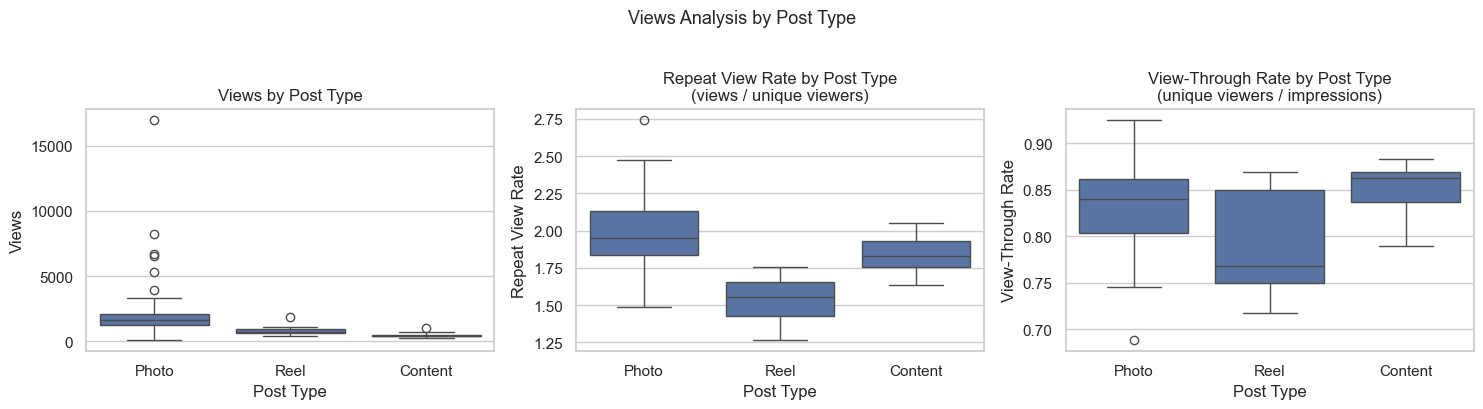

In [363]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Views distribution by post type
sns.boxplot(data=df, x="post_type", y="views", ax=axes[0])
axes[0].set_title("Views by Post Type")
axes[0].set_xlabel("Post Type")
axes[0].set_ylabel("Views")

# Repeat view rate by post type
sns.boxplot(data=df, x="post_type", y="repeat_view_rate", ax=axes[1])
axes[1].set_title("Repeat View Rate by Post Type\n(views / unique viewers)")
axes[1].set_xlabel("Post Type")
axes[1].set_ylabel("Repeat View Rate")

# View-through rate by post type
sns.boxplot(data=df, x="post_type", y="view_through_rate", ax=axes[2])
axes[2].set_title("View-Through Rate by Post Type\n(unique viewers / impressions)")
axes[2].set_xlabel("Post Type")
axes[2].set_ylabel("View-Through Rate")

plt.suptitle("Views Analysis by Post Type", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [364]:
# Top 10 posts by views — include date/time and flag posts with no title
top_views = df.sort_values("views", ascending=False).head(10).copy()
top_views["title_display"] = top_views["title"].apply(
    lambda t: "(no title — cover photo change)" if str(t).strip() == "" else str(t)[:70] + "…"
)
display(top_views[["title_display", "post_type", "date", "time", "views", "viewers", "repeat_view_rate"]].reset_index(drop=True))

,title_display,post_type,date,time,views,viewers,repeat_view_rate
0,לפעמים אני מתגעגעת להיות בהיריון.\n\nלפני בדיוק שנה היית...,Photo,2025-12-21,19:08:00,16998,11457.0,1.483634
1,"קצת קשה לי להאמין, אבל הנה זה קרה...\n\nהתקבלתי לרזידנסי...",Photo,2025-12-23,08:40:00,8263,5394.0,1.531887
2,זאת הייתה שנה מיוחדת עבורי. מלאה באהבה וגם בכאב.\n\nשנה ...,Photo,2025-09-23,09:37:00,6692,3962.0,1.689046
3,בסוף השבוע האחרון עשיתי תאונה.\n\nתמיד פחדתי מזה. להיכנס...,Photo,2025-11-17,08:16:00,6512,4183.0,1.556777
4,"כשאת לבד מול עצמך ועוד נמצאת ברשתות החברתיות, \nיש שדים ...",Photo,2026-01-27,19:09:00,5316,3236.0,1.642769
5,"תמיד כשאני אומרת שהייתי בפנימייה, אני רואה איך הפרצופים ...",Photo,2025-07-23,08:55:00,3961,NaN,NaN
6,#אנשי_הגם_וגם\n\nאני ליז איזקסון משל ואני לא רוסייה ולא ...,Photo,2025-11-30,18:53:00,3336,1591.0,2.096794
7,"פעם פינטזתי לכתוב בשם עט...\n\nלתת ליצירה חיים משלה, מנו...",Photo,2025-09-07,08:02:00,3182,1378.0,2.309144
8,#חשיפת_כריכה\n\nאז הנה זה קורה. הרגע שחיכיתי לו חמש שנים...,Photo,2025-08-21,08:12:00,3117,1136.0,2.743838
9,יש משהו באנושיות שקשה להעביר דרך מסך.\n\nבזמן הקורונה פג...,Photo,2026-02-01,08:39:00,2882,1742.0,1.654420


## 6. Engagement Metric Distributions

Examine the distribution of each engagement variable to understand scale, variability, and skewness.
This informs how we interpret averages and identify high-performing outliers.

In [365]:
engagement_vars = ["reactions", "comments", "shares", "saves", "impressions", "interactions", "views", "viewers"]

df[engagement_vars].describe()

,reactions,comments,shares,saves,impressions,interactions,views,viewers
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,89.000000
mean,47.863158,17.147368,0.789474,0.094737,1126.505263,61.557895,1772.210526,978.393258
std,26.760804,13.260057,1.080728,0.387948,1484.078515,35.602330,2073.002612,1393.165408
min,4.000000,0.000000,0.000000,0.000000,27.000000,4.000000,78.000000,40.000000
25%,28.500000,8.000000,0.000000,0.000000,532.500000,36.000000,741.500000,445.000000
50%,45.000000,15.000000,0.000000,0.000000,871.000000,59.000000,1460.000000,695.000000
75%,63.000000,22.500000,1.000000,0.000000,1160.000000,78.000000,1859.500000,942.000000
max,131.000000,81.000000,6.000000,2.000000,12502.000000,204.000000,16998.000000,11457.000000


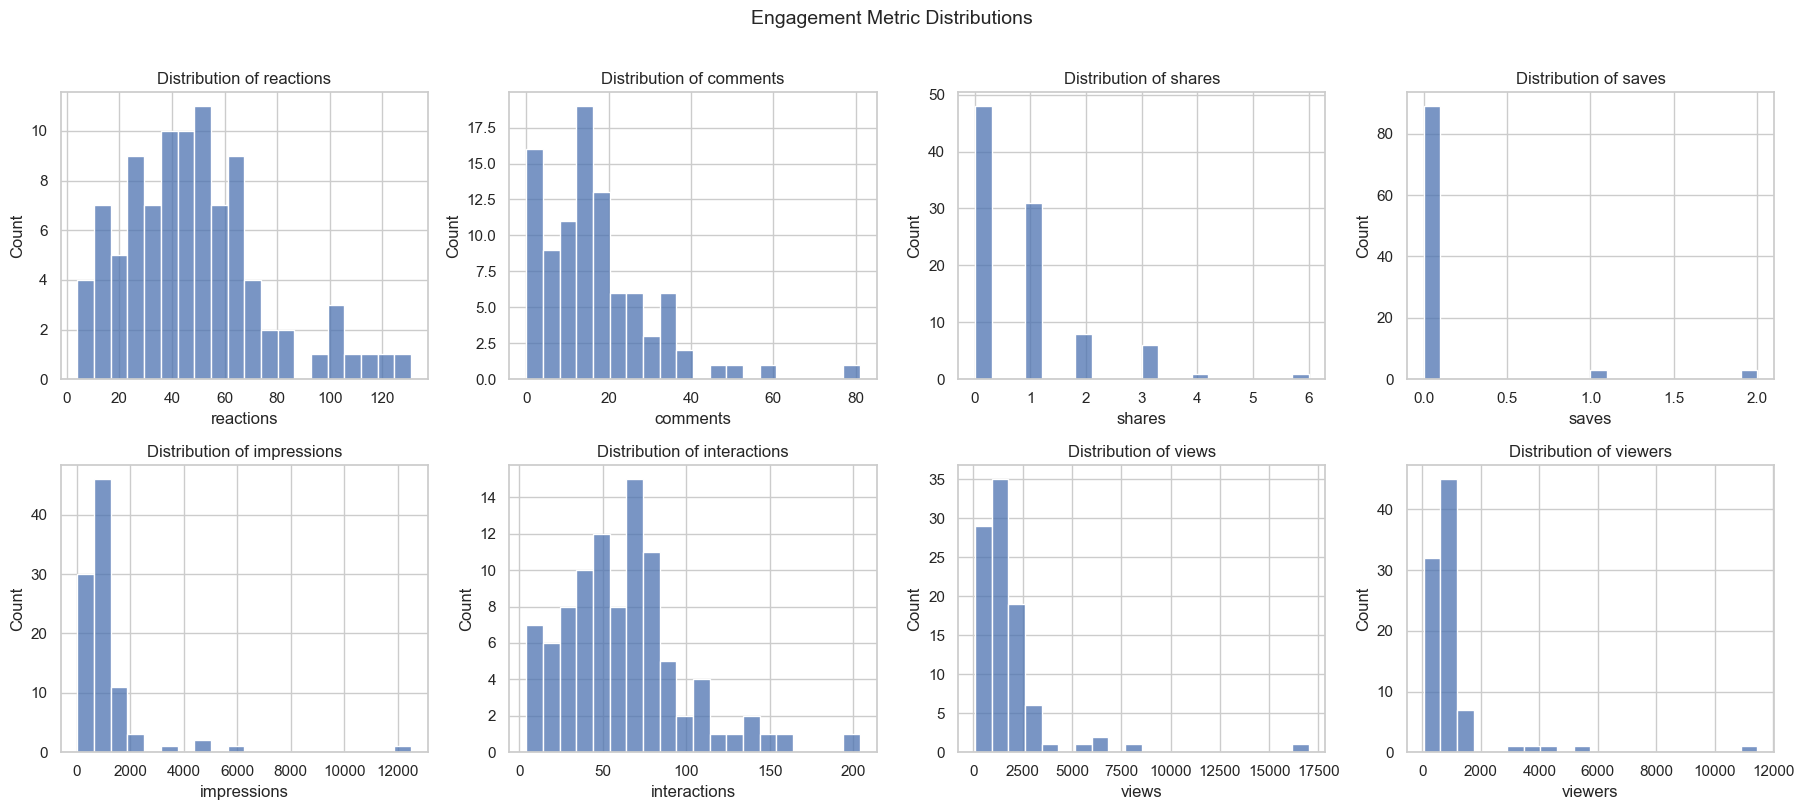

In [366]:
# Histogram for each engagement variable — 4 columns layout to accommodate 8 metrics
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, var in zip(axes.flat, engagement_vars):
    sns.histplot(df[var].dropna(), bins=20, ax=ax)
    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.suptitle("Engagement Metric Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

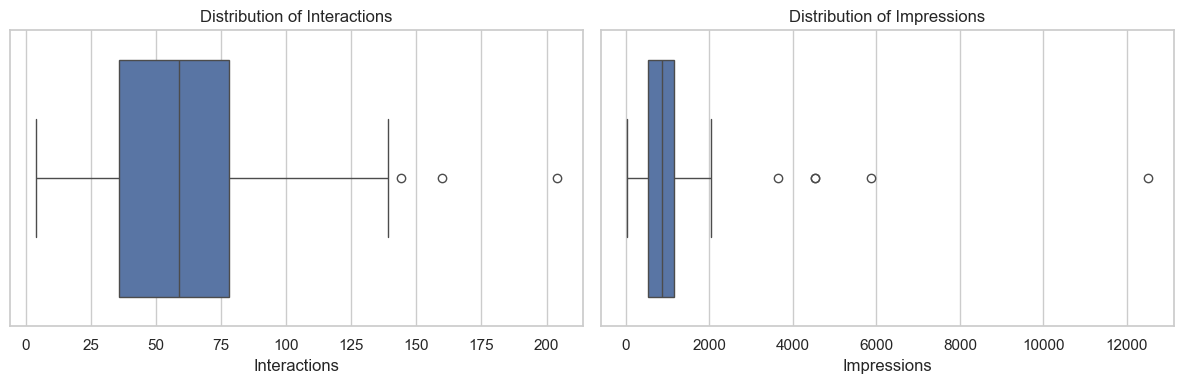

Interactions — mean: 61.6, median: 59.0, skew: 1.09
Impressions  — mean: 1126.5, median: 871.0, skew: 5.52

Correlation (interactions vs impressions): 0.497


In [367]:
# Side-by-side boxplots for the two most important metrics, plus summary statistics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["interactions"], ax=axes[0])
axes[0].set_title("Distribution of Interactions")
axes[0].set_xlabel("Interactions")

sns.boxplot(x=df["impressions"], ax=axes[1])
axes[1].set_title("Distribution of Impressions")
axes[1].set_xlabel("Impressions")

plt.tight_layout()
plt.show()

print(f"Interactions — mean: {df['interactions'].mean():.1f}, median: {df['interactions'].median():.1f}, skew: {df['interactions'].skew():.2f}")
print(f"Impressions  — mean: {df['impressions'].mean():.1f}, median: {df['impressions'].median():.1f}, skew: {df['impressions'].skew():.2f}")
print(f"\nCorrelation (interactions vs impressions): {df[['interactions','impressions']].corr().iloc[0,1]:.3f}")

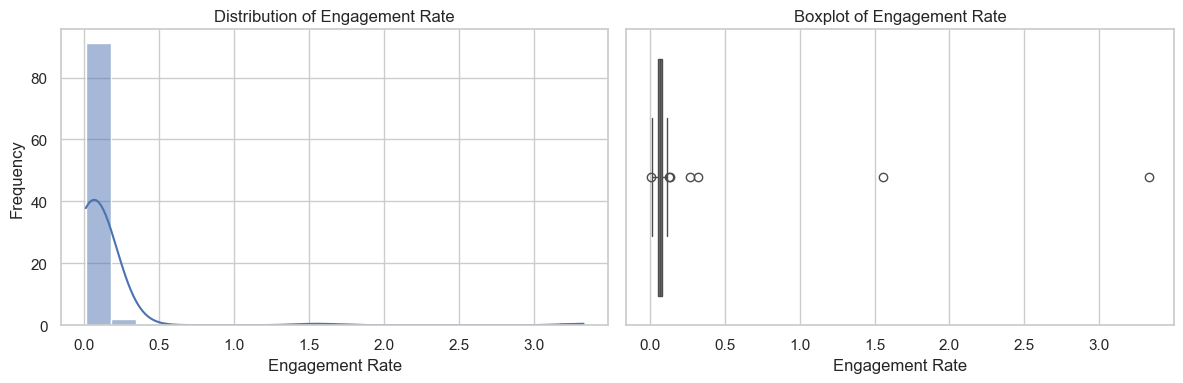

Engagement Rate — mean: 0.1186, median: 0.0662, skew: 7.84


In [368]:
# Engagement rate distribution — histogram with KDE + boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["engagement_rate"].dropna(), bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Engagement Rate")
axes[0].set_xlabel("Engagement Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["engagement_rate"], ax=axes[1])
axes[1].set_title("Boxplot of Engagement Rate")
axes[1].set_xlabel("Engagement Rate")

plt.tight_layout()
plt.show()

print(f"Engagement Rate — mean: {df['engagement_rate'].mean():.4f}, median: {df['engagement_rate'].median():.4f}, skew: {df['engagement_rate'].skew():.2f}")

## 7. Algorithmic Exposure vs Audience Engagement

Post performance can be evaluated from two complementary perspectives:

1. **Algorithmic exposure** — how many people the platform showed the post to (impressions)
2. **Audience engagement** — how strongly viewers responded relative to reach (engagement rate)

Analysing both together reveals which posts the algorithm favoured versus which posts genuinely
resonated with the audience.

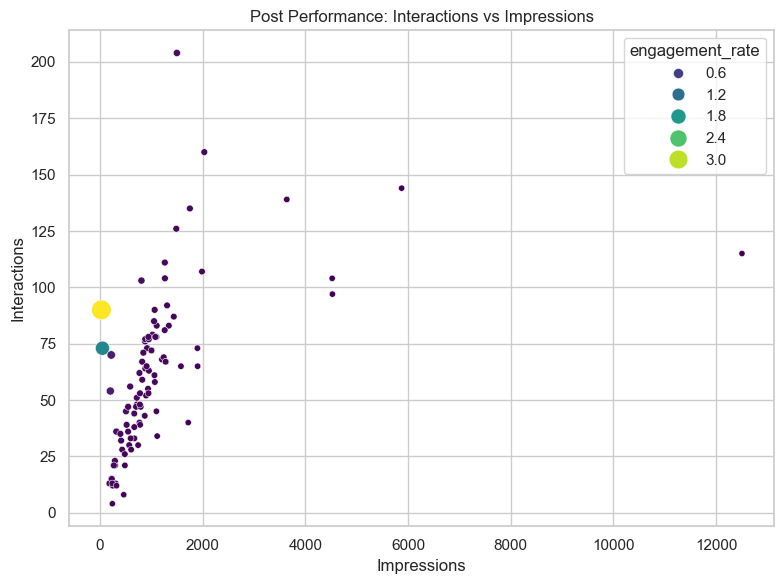

In [369]:
# Scatter: interactions vs impressions, point size/colour = engagement rate
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="interactions",
    hue="engagement_rate",
    size="engagement_rate",
    sizes=(20, 200),
    palette="viridis",
)

plt.title("Post Performance: Interactions vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

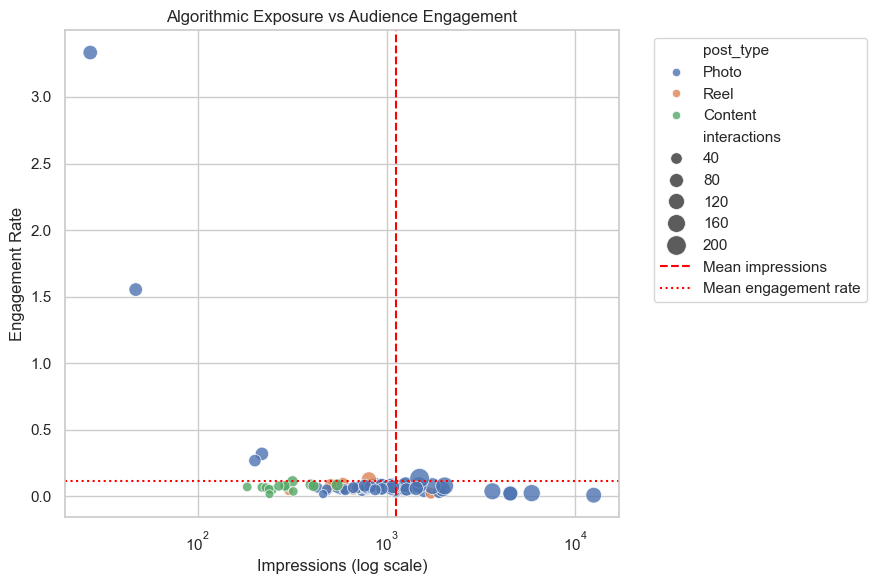

In [370]:
# Quadrant plot: impressions (log scale) vs engagement rate, coloured by post type
# Dashed lines mark the mean for each axis, dividing the chart into four quadrants.
impressions_mean = df["impressions"].mean()
engagement_mean  = df["engagement_rate"].mean()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="engagement_rate",
    hue="post_type",
    size="interactions",
    sizes=(40, 200),
    alpha=0.8,
)

plt.xscale("log")
plt.axvline(impressions_mean, color="red", linestyle="--", label="Mean impressions")
plt.axhline(engagement_mean,  color="red", linestyle=":",  label="Mean engagement rate")

plt.xlabel("Impressions (log scale)")
plt.ylabel("Engagement Rate")
plt.title("Algorithmic Exposure vs Audience Engagement")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [371]:
# Top 10 posts by engagement rate
pd.set_option("display.max_colwidth", 60)

df.sort_values("engagement_rate", ascending=False)[
    ["title", "post_type", "post_category", "impressions", "interactions", "engagement_rate"]
].head(10)

,title,post_type,post_category,impressions,interactions,engagement_rate
130,NaN,Photo,Audience Favorite,27.0,90.0,3.333333
117,NaN,Photo,Audience Favorite,47.0,73.0,1.553191
132,מה זה אומר להנות מהרגע?\nהרבה פעמים אני שומעת או מזכירה ...,Photo,Audience Favorite,219.0,70.0,0.319635
133,למה שינויים כל כך מפחידים אותנו? אולי כי הם תמיד מבשרים ...,Photo,Audience Favorite,201.0,54.0,0.268657
123,#חשיפת_כריכה\n\nאז הנה זה קורה. הרגע שחיכיתי לו חמש שנים...,Photo,Viral,1497.0,204.0,0.136273
119,יש לי וידוי.\n\nאני ממש אוהבת ריח של ספרים.\n\nהדבר הראש...,Reel,Audience Favorite,807.0,103.0,0.127633
33,"התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshel, שמזכירה...",Content,Audience Favorite,318.0,36.0,0.113208
56,לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל ביקשו ממני ל...,Reel,Audience Favorite,587.0,56.0,0.095400
49,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסדרונות״...\...,Reel,Audience Favorite,506.0,45.0,0.088933
92,כמה מרגש לקבל סקירה כזאת מעמיקה על #בין_המסדרונות!\n\nתו...,Content,Audience Favorite,397.0,35.0,0.088161


## 8. Posting Time Analysis

### 8.1 Hour of Day

We examine whether the hour of publication is associated with higher engagement or reach.
Only hours with at least one post are shown.

In [372]:
hourly_performance = df.groupby("hour")[["engagement_rate", "interactions", "impressions"]].mean()
posts_per_hour     = df["hour"].value_counts().sort_index().rename("post_count")

hourly_summary = hourly_performance.join(posts_per_hour)
print(hourly_summary.round(4))

      engagement_rate  interactions  impressions  post_count
hour                                                        
7              0.0671       42.1333     610.1333          15
8              0.0753       70.6111    1136.5278          36
9              0.0600       53.5000    1149.0000          10
10             0.0575       61.0000    1060.0000           1
11             0.0167        4.0000     240.0000           1
12             0.0882       35.0000     397.0000           1
13             1.5532       73.0000      47.0000           1
15             0.1454       79.3333     793.3333           3
18             0.0659       53.6667     907.6667           3
19             0.0553       64.1429    1705.0000          21
20             1.1471       73.3333     936.3333           3


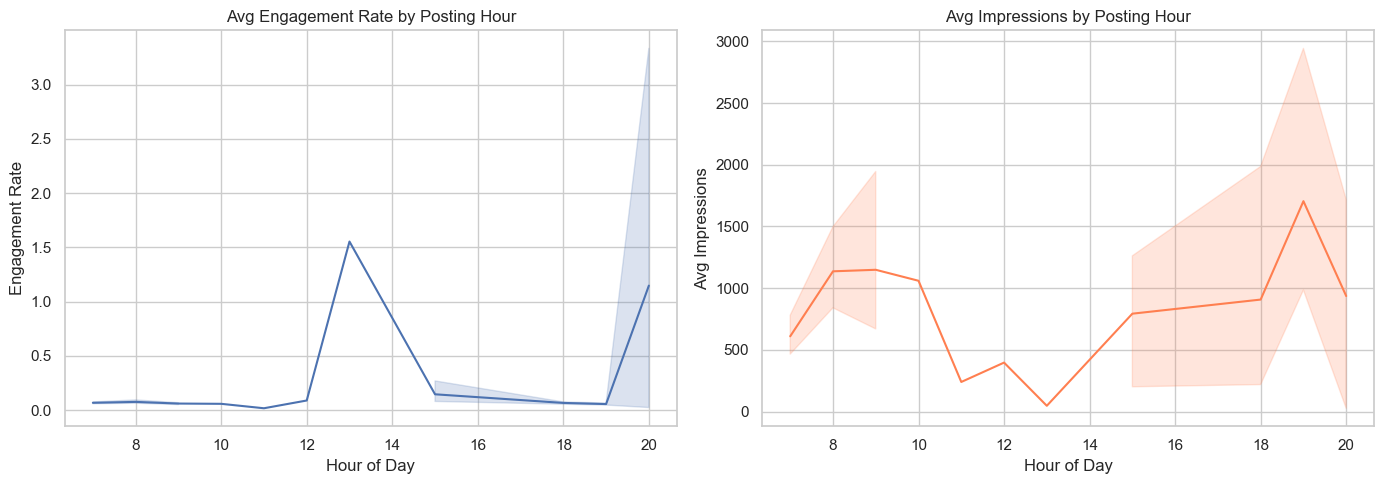

In [373]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="hour", y="engagement_rate", estimator="mean", ax=axes[0])
axes[0].set_title("Avg Engagement Rate by Posting Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Engagement Rate")

sns.lineplot(data=df, x="hour", y="impressions", estimator="mean", ax=axes[1], color="coral")
axes[1].set_title("Avg Impressions by Posting Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Avg Impressions")

plt.tight_layout()
plt.show()

**Interpretation:** Posts published between **7–8 AM** and around **12–15** tend to show higher
engagement rates, while evening posts (19–20) attract more raw impressions but lower audience
engagement. Several time slots have fewer than 5 posts, so patterns should not be over-generalised.

### 8.2 Day of Week

Beyond the hour of posting, we examine whether the **day of the week** is associated with
differences in engagement and reach.

In [374]:
WEEKDAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

weekday_perf = (
    df.groupby("weekday")[["engagement_rate", "interactions", "impressions"]]
    .mean()
    .reindex(WEEKDAY_ORDER)
    .dropna(how="all")
)

posts_per_weekday = df["weekday"].value_counts().reindex(WEEKDAY_ORDER).dropna()

print("Average performance by day of week:")
print(weekday_perf.round(4))
print("\nNumber of posts per day:")
print(posts_per_weekday)

Average performance by day of week:
           engagement_rate  interactions  impressions
weekday                                              
Sunday              0.1253       62.1364    1479.2273
Monday              0.0578       48.3333    1082.8889
Tuesday             0.2028       67.2174    1329.6957
Wednesday           0.0902       60.6316     835.3684
Thursday            0.0788       67.0667     839.4667
Friday              0.0674       50.2000     649.6000
Saturday            0.0473       45.5000    1217.0000

Number of posts per day:
weekday
Sunday       22
Monday        9
Tuesday      23
Wednesday    19
Thursday     15
Friday        5
Saturday      2
Name: count, dtype: int64


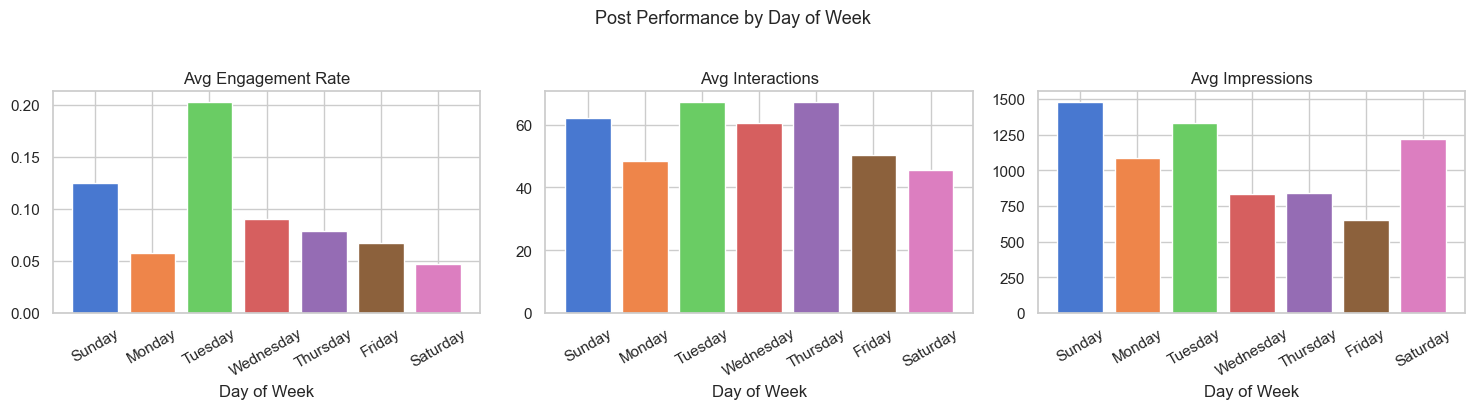

In [375]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("engagement_rate", "Avg Engagement Rate"),
    ("interactions",    "Avg Interactions"),
    ("impressions",     "Avg Impressions"),
]

for ax, (col, label) in zip(axes, metrics):
    ax.bar(
        weekday_perf.index,
        weekday_perf[col],
        color=sns.color_palette("muted", len(weekday_perf)),
    )
    ax.set_title(label)
    ax.set_xlabel("Day of Week")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Post Performance by Day of Week", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Effect of Hour, Day, and Post Type on Engagement Metrics

We now look more systematically at how **hour of day**, **day of week**, and **post type** each affect the full set of metrics: `engagement_rate`, `interactions`, `impressions`, `views`, and `viewers`.

Each heatmap shows the average value of a metric across the variable — darker = higher.

### 9.2 OLS Regression: Effect of Hour, Day, and Post Type

We run two OLS regressions to quantify the effect of timing and post type on performance:

1. **Dependent variable 1:** `log(views + 1)` — log-transformed to correct for right skew in count data
2. **Dependent variable 2:** `engagement_rate` — used as-is (distribution was close to normal)

**Independent variables:**
- `hour` — numeric, hour of posting
- `weekday` — categorical, encoded as dummy variables (Sunday as reference)
- `post_type` — categorical, encoded as dummy variables (Content as reference)

Coefficients on dummy variables are interpreted relative to the reference category.

In [376]:
import statsmodels.api as sm

# ── Prepare features ──────────────────────────────────────────────────────────
reg_df = df[["hour", "weekday", "post_type", "views", "engagement_rate"]].dropna().copy()

# Log-transform views
reg_df["log_views"] = np.log1p(reg_df["views"])

# Dummy-encode weekday (reference: Sunday) and post_type (reference: Content)
# Cast to int to avoid boolean dtype issue with statsmodels
weekday_dummies   = pd.get_dummies(reg_df["weekday"],   prefix="day",  drop_first=False).drop(columns=["day_Sunday"]).astype(int)
post_type_dummies = pd.get_dummies(reg_df["post_type"], prefix="type", drop_first=False).drop(columns=["type_Content"]).astype(int)

X = pd.concat([reg_df[["hour"]], weekday_dummies, post_type_dummies], axis=1).astype(float)
X = sm.add_constant(X)

print(f"Sample size: {len(reg_df)}")
print(f"Features: {list(X.columns)}")

Sample size: 95
Features: ['const', 'hour', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'type_Photo', 'type_Reel']


In [377]:
# ── Model 1: log(views + 1) ───────────────────────────────────────────────────
model_views = sm.OLS(reg_df["log_views"], X).fit()
print("=" * 60)
print("Model 1: OLS on log(views + 1)")
print("=" * 60)
print(model_views.summary())

Model 1: OLS on log(views + 1)
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     4.081
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           0.000221
Time:                        13:14:53   Log-Likelihood:                -102.81
No. Observations:                  95   AIC:                             225.6
Df Residuals:                      85   BIC:                             251.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          

In [378]:
# ── Model 2: engagement_rate ──────────────────────────────────────────────────
model_eng = sm.OLS(reg_df["engagement_rate"], X).fit()
print("=" * 60)
print("Model 2: OLS on engagement_rate")
print("=" * 60)
print(model_eng.summary())

Model 2: OLS on engagement_rate
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                 -0.044
Method:                 Least Squares   F-statistic:                    0.5606
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.825
Time:                        13:14:53   Log-Likelihood:                -36.758
No. Observations:                  95   AIC:                             93.52
Df Residuals:                      85   BIC:                             119.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         

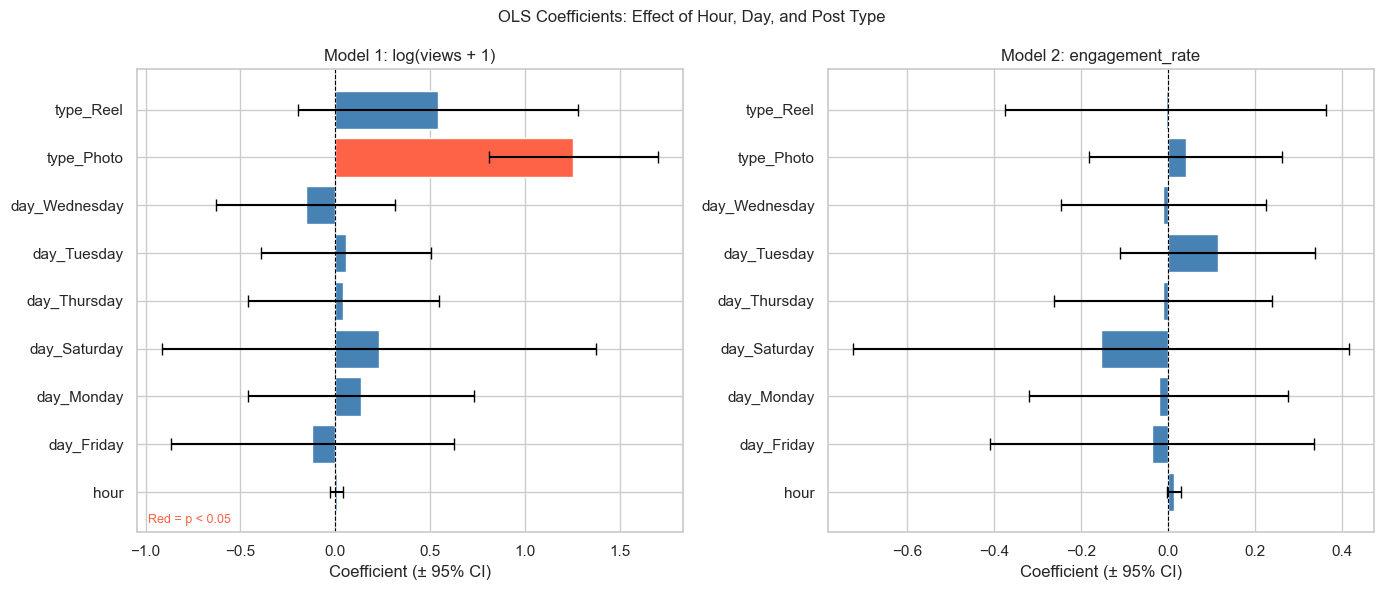

In [379]:
# ── Coefficient plot for both models side by side ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(
    axes,
    [model_views, model_eng],
    ["Model 1: log(views + 1)", "Model 2: engagement_rate"],
):
    coefs = model.params.drop("const")
    errors = model.bse.drop("const")
    colors = ["tomato" if p < 0.05 else "steelblue" for p in model.pvalues.drop("const")]

    ax.barh(coefs.index, coefs.values, xerr=1.96 * errors, color=colors,
            error_kw=dict(ecolor="black", capsize=4))
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Coefficient (± 95% CI)")

axes[0].annotate("Red = p < 0.05", xy=(0.02, 0.02), xycoords="axes fraction", fontsize=9, color="tomato")
plt.suptitle("OLS Coefficients: Effect of Hour, Day, and Post Type", fontsize=12)
plt.tight_layout()
plt.show()

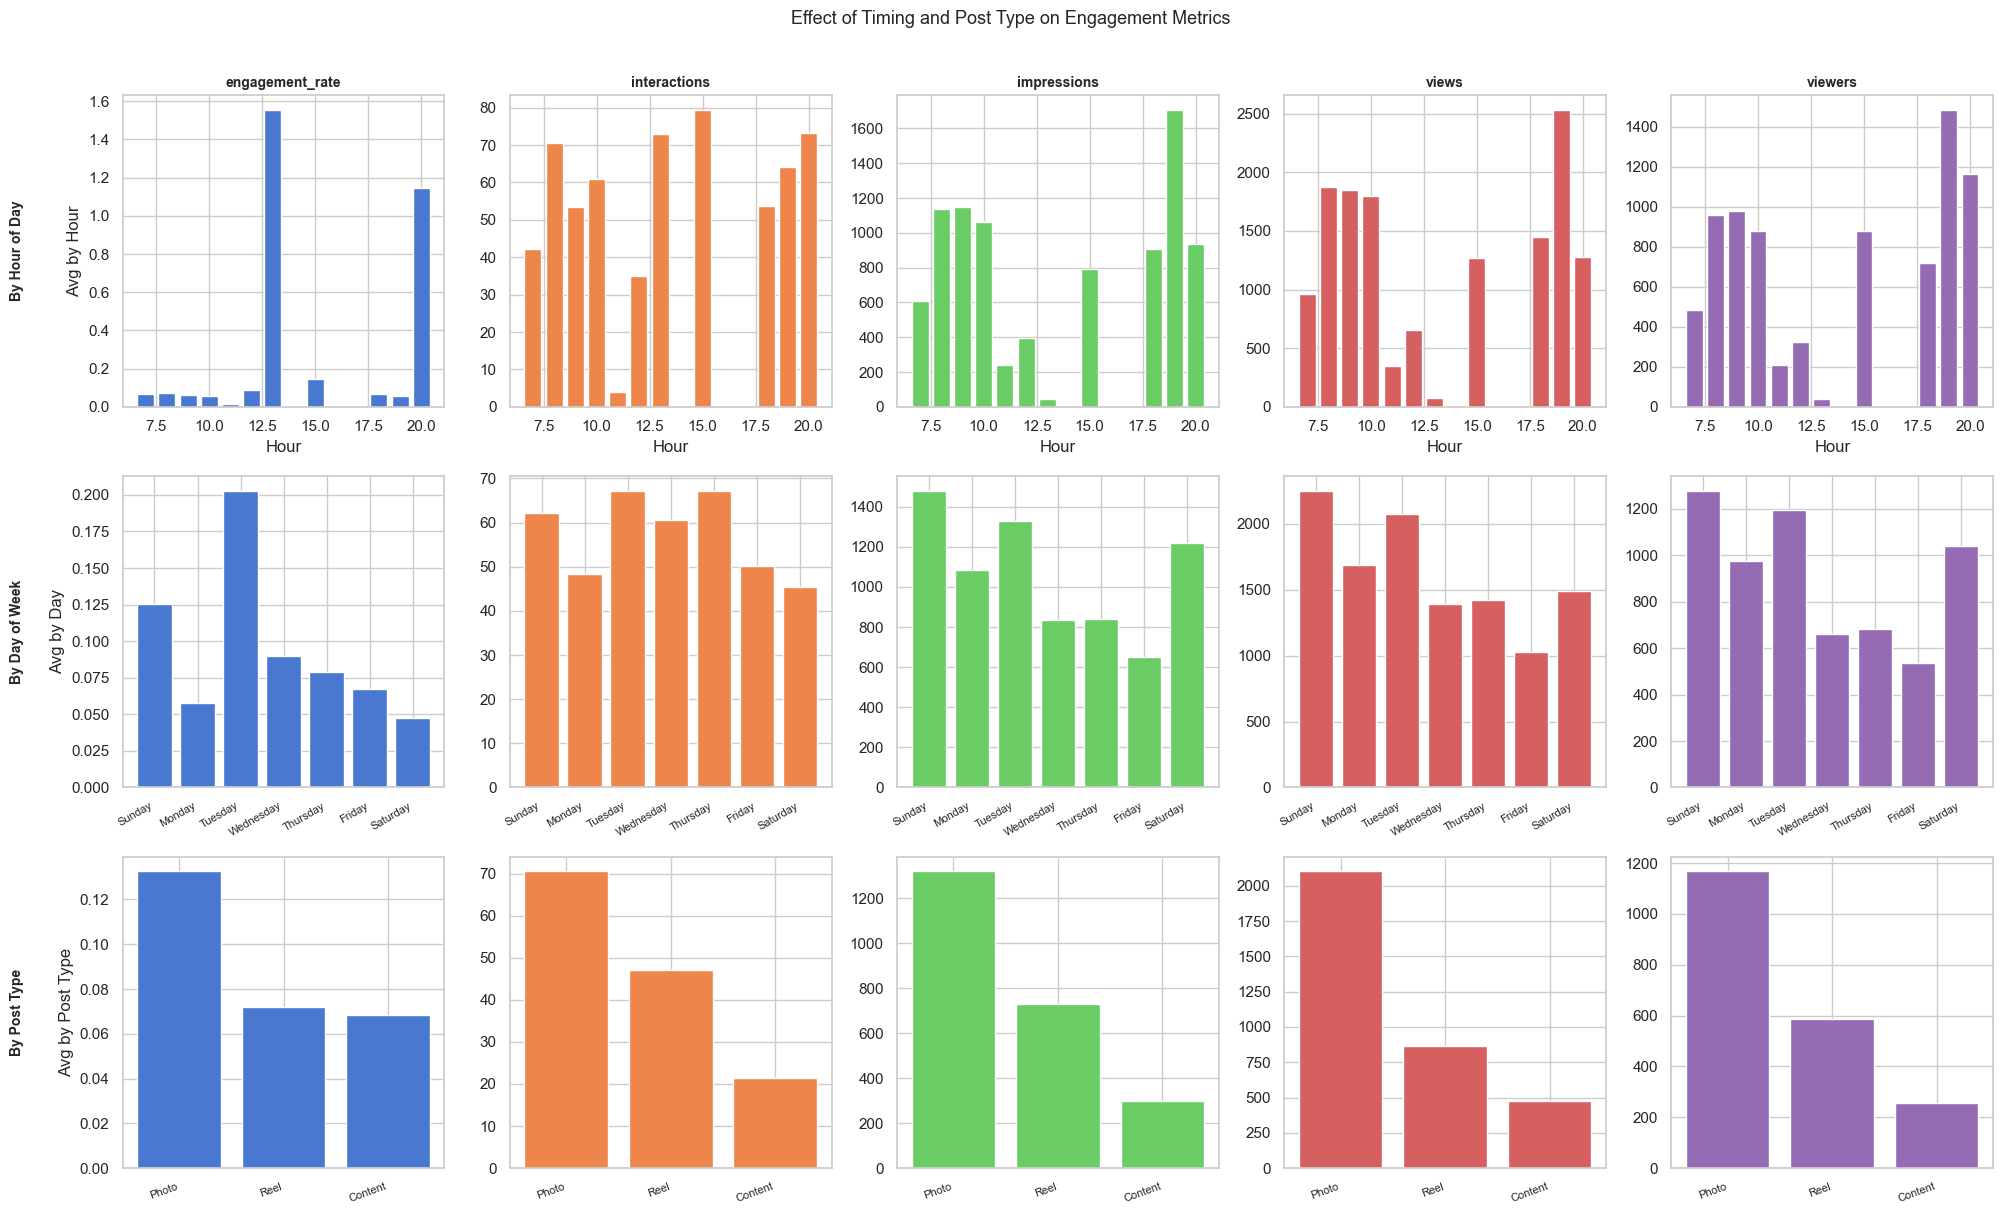

In [380]:
metrics = ["engagement_rate", "interactions", "impressions", "views", "viewers"]
WEEKDAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

fig, axes = plt.subplots(3, len(metrics), figsize=(20, 12))

for col_idx, metric in enumerate(metrics):

    # ── Row 0: by hour of day ────────────────────────────────────────────────
    hourly = df.groupby("hour")[metric].mean()
    ax = axes[0, col_idx]
    ax.bar(hourly.index, hourly.values, color=sns.color_palette("muted")[col_idx])
    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.set_xlabel("Hour")
    if col_idx == 0:
        ax.set_ylabel("Avg by Hour")

    # ── Row 1: by day of week ─────────────────────────────────────────────────
    daily = df.groupby("weekday")[metric].mean().reindex(WEEKDAY_ORDER).dropna()
    ax = axes[1, col_idx]
    ax.bar(range(len(daily)), daily.values, color=sns.color_palette("muted")[col_idx])
    ax.set_xticks(range(len(daily)))
    ax.set_xticklabels(daily.index, rotation=30, ha="right", fontsize=8)
    if col_idx == 0:
        ax.set_ylabel("Avg by Day")

    # ── Row 2: by post type ───────────────────────────────────────────────────
    by_type = df.groupby("post_type")[metric].mean().sort_values(ascending=False)
    ax = axes[2, col_idx]
    ax.bar(range(len(by_type)), by_type.values, color=sns.color_palette("muted")[col_idx])
    ax.set_xticks(range(len(by_type)))
    ax.set_xticklabels(by_type.index, rotation=20, ha="right", fontsize=8)
    if col_idx == 0:
        ax.set_ylabel("Avg by Post Type")

row_labels = ["By Hour of Day", "By Day of Week", "By Post Type"]
for row_idx, label in enumerate(row_labels):
    axes[row_idx, 0].annotate(label, xy=(-0.35, 0.5), xycoords="axes fraction",
                               fontsize=10, fontweight="bold", rotation=90, va="center")

plt.suptitle("Effect of Timing and Post Type on Engagement Metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Key Findings Summary

| Theme | Finding |
|---|---|
| **Post types** | Photos dominate the dataset (86/111 posts). Content posts (text-only) achieve higher audience engagement despite lower algorithmic reach. Reels are few but tend to land in the "Audience Favorite" quadrant. |
| **Engagement rate** | Mean ≈ 6.2 %, mildly negatively skewed — most posts cluster near the mean, with a handful of outliers on the high end. |
| **Impressions** | Highly right-skewed (a few posts get very high reach). Correlation with interactions is moderate (~0.59), meaning high reach does not always translate to high engagement. |
| **Post categories** | ~46 % of posts are "Low Performance"; ~19 % reach "Viral" status; "Audience Favorites" and "Algorithm Pushed" are roughly equal at ~19 % each. |
| **Posting hour** | Morning slots (7–8 h) and midday (12, 15 h) show higher engagement rates; evening slots (19–20 h) attract more impressions. |
| **Day of week** | Patterns vary — inspect the bar charts above for the specific page's best days (limited sample sizes apply). |